In [1]:
import numpy as np
import scipy.sparse as sp

## Interactions Basis

In [2]:
from scipy.stats import zscore
from scdesigner.datasets import acinar
from scdesigner.simulators import SpatialNegBinCopula

example_sce = acinar()
example_sce.obs["spatial1"] = zscore(example_sce.obs["spatial1"])
example_sce.obs["spatial2"] = zscore(example_sce.obs["spatial2"])

sim = SpatialNegBinCopula(basis="tps", mean_df=100, disp_df=20)
sim.fit(example_sce)


Epoch 51/500, Loss: 2.2121, Val Loss: 1.8159


Estimating copula correlation: 100%|██████████| 3/3 [00:06<00:00,  2.22s/it]


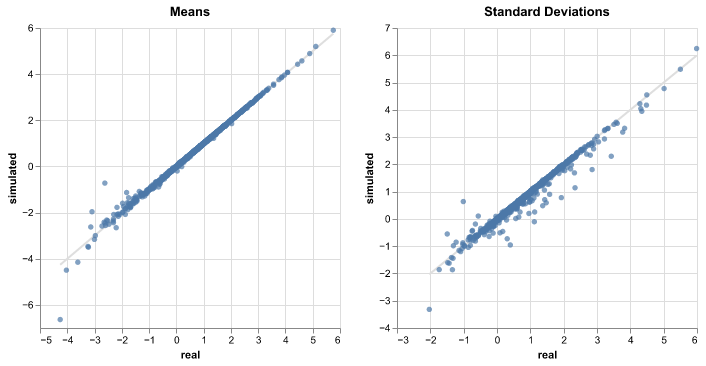

In [3]:
from scdiagnostics import compare_moments
import altair
altair.renderers.enable('png')

samples = sim.sample()
compare_moments(example_sce, samples)

In [4]:
from scdesigner.simulators import NegBinCopula

# train simulator
sim_orig = NegBinCopula(
    mean_formula="~ 0 + cell_type + bs(spatial1, df=5, include_intercept=False) * bs(spatial2, df=5, include_intercept=False)",
    dispersion_formula="~ 0 + bs(spatial1, df=3, include_intercept=False) * bs(spatial2, df=3, include_intercept=False)",
    copula_formula="~ 1"
)
sim_orig.fit(example_sce, max_epochs=200)

Epoch 90/200, Loss: 1.7875, Val Loss: 1.7913


Estimating copula correlation: 100%|██████████| 3/3 [00:19<00:00,  6.33s/it]


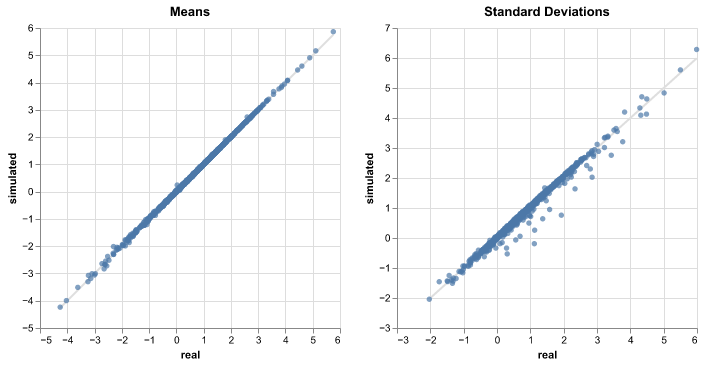

In [5]:
samples_orig = sim_orig.sample()
compare_moments(example_sce, samples_orig)

## Visualizations

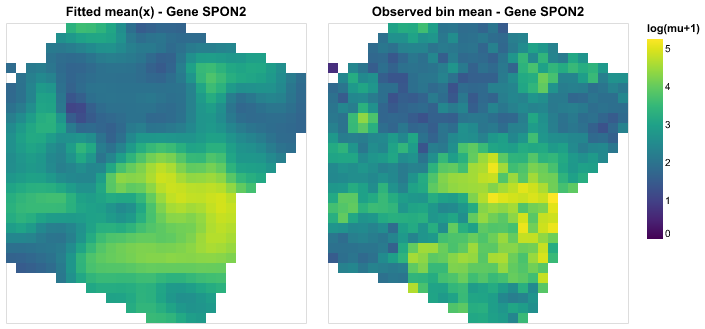

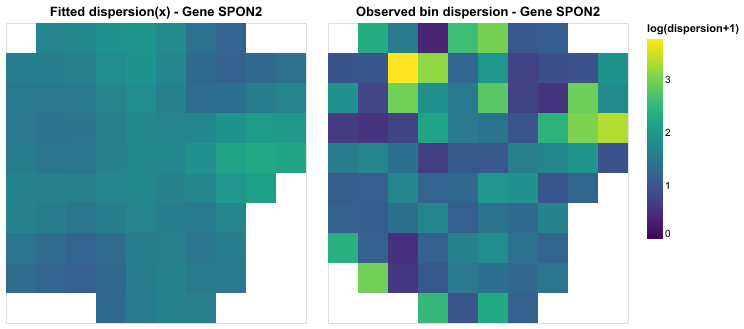

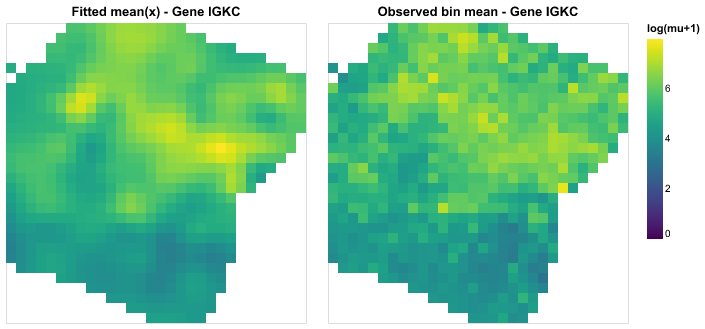

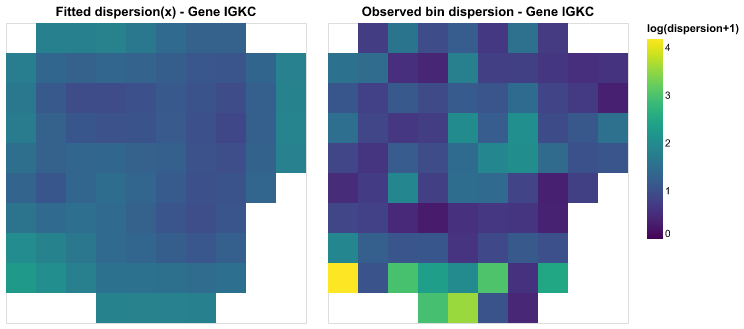

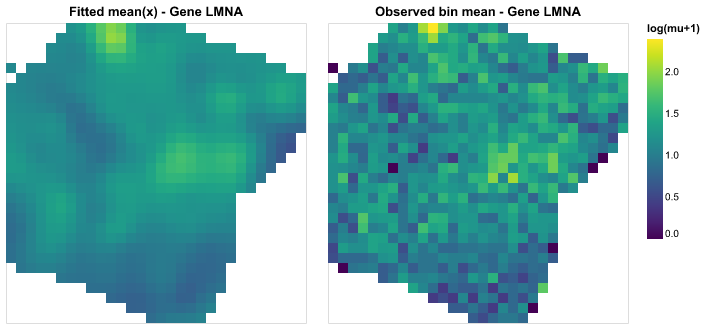

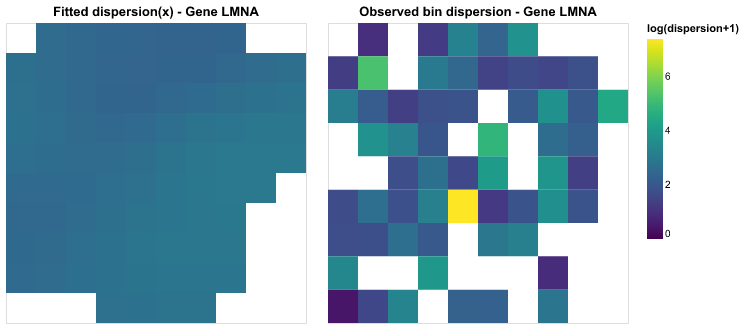

In [6]:
from scdiagnostics import plot_mean_surface, plot_dispersion_surface

# Find genes with largest variance in both datasets
X_real = example_sce.X.toarray() if sp.issparse(example_sce.X) else np.array(example_sce.X)
X_sim = samples.X.toarray() if sp.issparse(samples.X) else np.array(samples.X)

var_real = np.var(X_real, axis=0)
var_sim = np.var(X_sim, axis=0)

# Create scatterplots of real vs. sim data
for gene_idx in [0, 26, 738]:
    chart = plot_mean_surface(sim, example_sce, gene=gene_idx)
    display(chart)

    chart = plot_dispersion_surface(sim, example_sce, gene=gene_idx)
    display(chart)